In [1]:
! pip install transformers lime shap torch ipython

In [2]:
MODEL_PATH = "./codebert-base-mlm"
LIME_SAMPLES = 500

In [20]:
# Loading the model and tokenizer
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification, TextClassificationPipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
import random
import json

model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH, output_attentions=True)
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

pipeline = TextClassificationPipeline(
    model=model,
    tokenizer=tokenizer,
    top_k=None, 
    truncation=True,
    padding=True
)

Device set to use cpu


In [ ]:
f = open("./data/packet_inspection/packets_dataset.jsonl", "r")
lines = []
for x in f.readlines():
    lines.append(json.loads(x))
inputs_to_explain = [s["text"] for s in lines]
classes_of_inputs = [s["class"] for s in lines]
# random.shuffle(inputs_to_explain)
# print(inputs_to_explain)

In [10]:
# Base model output
model_outputs = pipeline(inputs_to_explain, truncation=True, padding=True)
print(model_outputs)
class_names = ["Adware",
               "Backdoor", 
               "Botnet", 
               "CGI", 
               "Code-execution", 
               "DDos", 
               "Dir-Traversal", 
               "Dos",
               "Info-Disclosure", 
               "Injection", 
               "Other", 
               "Overflow", 
               "Ransonware", 
               "Remote-file-Inclusion",
               "Scanner", 
               "Spyware", 
               "Trojan", 
               "Virus", 
               "Webshell", 
               "Worm",
               "XSS"]
# print(f"{class_names=}")

[[{'label': 'Info-Disclosure', 'score': 0.9951329827308655}, {'label': 'Other', 'score': 0.004101261496543884}, {'label': 'Dir-Traversal', 'score': 0.0004353585245553404}, {'label': 'Scanner', 'score': 0.00012929081276524812}, {'label': 'Code-execution', 'score': 5.88141665502917e-05}, {'label': 'Injection', 'score': 3.6394842027220875e-05}, {'label': 'XSS', 'score': 2.1178369934204966e-05}, {'label': 'Remote-file-Inclusion', 'score': 1.758739927026909e-05}, {'label': 'Botnet', 'score': 1.3372157809499186e-05}, {'label': 'Dos', 'score': 1.0295450010744389e-05}, {'label': 'Overflow', 'score': 8.197016541089397e-06}, {'label': 'Backdoor', 'score': 7.452102636307245e-06}, {'label': 'Webshell', 'score': 5.829247584188124e-06}, {'label': 'Worm', 'score': 5.523522759176558e-06}, {'label': 'Trojan', 'score': 5.395909283834044e-06}, {'label': 'CGI', 'score': 4.302281467971625e-06}, {'label': 'Adware', 'score': 1.5241505479934858e-06}, {'label': 'DDos', 'score': 1.4036016864338308e-06}, {'label

In [ ]:
# LIME
from lime.lime_text import LimeTextExplainer
import torch
class LIME_predictor():
    def __init__(self, model, tokenizer):
        self.model=model
        self.tokenizer=tokenizer
        
    def prediction(self, texts):
        outputs = self.model(**self.tokenizer(texts, return_tensors="pt", padding=True, truncation=True))
        tensor_logits = outputs[0]
        probabilities = torch.nn.functional.softmax(tensor_logits, dim=1).detach().numpy()
        return probabilities

def LIME_explain_single(explainer, input_string, pipeline, num_features=15, num_samples=LIME_SAMPLES, top_labels=1):
    results = explainer.explain_instance(input_string, pipeline, num_features=num_features, num_samples=num_samples, top_labels=top_labels)
    # results.show_in_notebook(text=input_string)
    
    return results.as_list(label=results.top_labels[0])
    

lime_explainer = LimeTextExplainer(class_names=class_names)
lime_words = []
predictor = LIME_predictor(model, tokenizer)
for input_string in tqdm(inputs_to_explain):
    lime_words.append(LIME_explain_single(lime_explainer, input_string, predictor.prediction))

# x is a list of tuples (word, weight)
placeholder = [print(json.dumps({"class": classes_of_inputs[i], "words": [w for w, _ in x], "weights": [w for _, w in x]})) for i,x in enumerate(lime_words)]

100%|██████████| 258/258 [1:37:26<00:00, 22.66s/it] 

Important words for input 0:  [(np.str_('adware'), 0.3168455697005949), (np.str_('source'), -0.2395851790402032), (np.str_('GET'), 0.19537571176156643), (np.str_('8859'), 0.1843786345430017), (np.str_('US'), 0.14673748804048892), (np.str_('1'), -0.13866038538203979), (np.str_('HTTP'), 0.13840780763188817), (np.str_('8'), 0.12883575676341869), (np.str_('Agent'), 0.1167254133574336), (np.str_('deflate'), 0.10448047743275711), (np.str_('malicious'), 0.09448753596345381), (np.str_('7'), 0.07841470717299732), (np.str_('q'), 0.07818525474520717), (np.str_('Host'), -0.07697904184526053), (np.str_('gzip'), -0.050295746462728434)]
Important words for input 1:  [(np.str_('inject_ads'), 0.4057713750868244), (np.str_('8'), 0.1562972099655036), (np.str_('legit'), 0.12964017064132952), (np.str_('utf'), 0.103996665479171), (np.str_('8859'), 0.09497898831249951), (np.str_('alive'), 0.09489044388962553), (np.str_('7'), 0.0863174549488614), (np.str_('com'), 0.0859155229756764), (np.str_('evil'), 0.08353

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   0%|          | 1/258 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   1%|          | 3/258 [01:15<1:30:33, 21.31s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 258/258 [2:32:39<00:00, 34.29s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 259it [2:33:11, 35.63s/it]                         


Adware feature importance


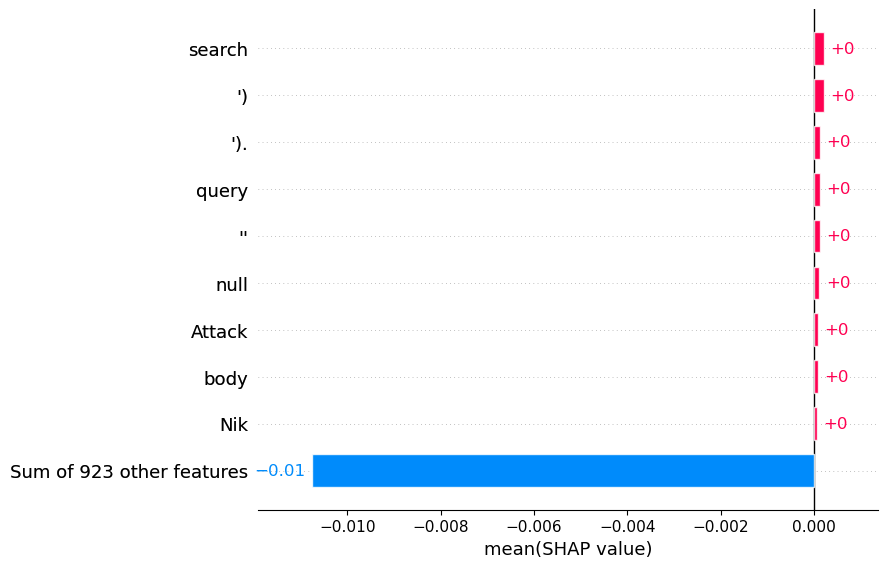

Backdoor feature importance


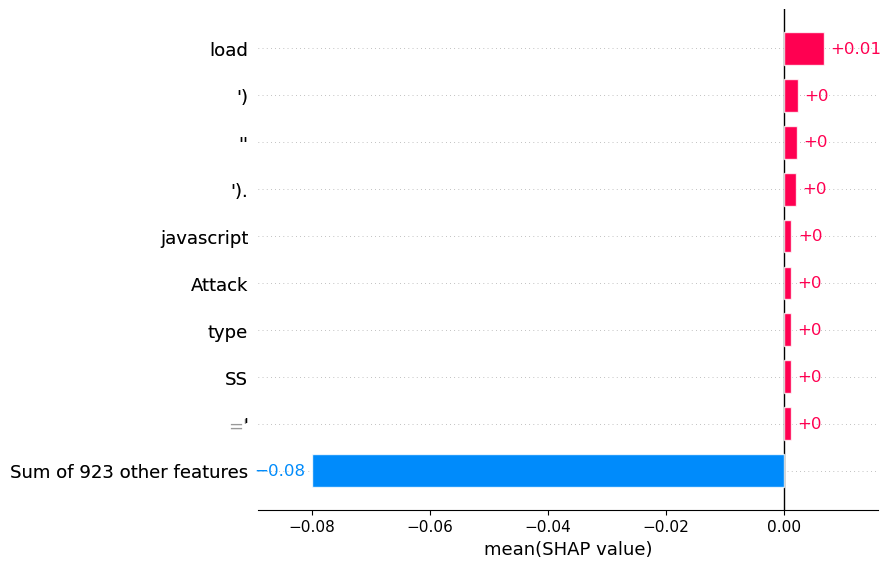

Botnet feature importance


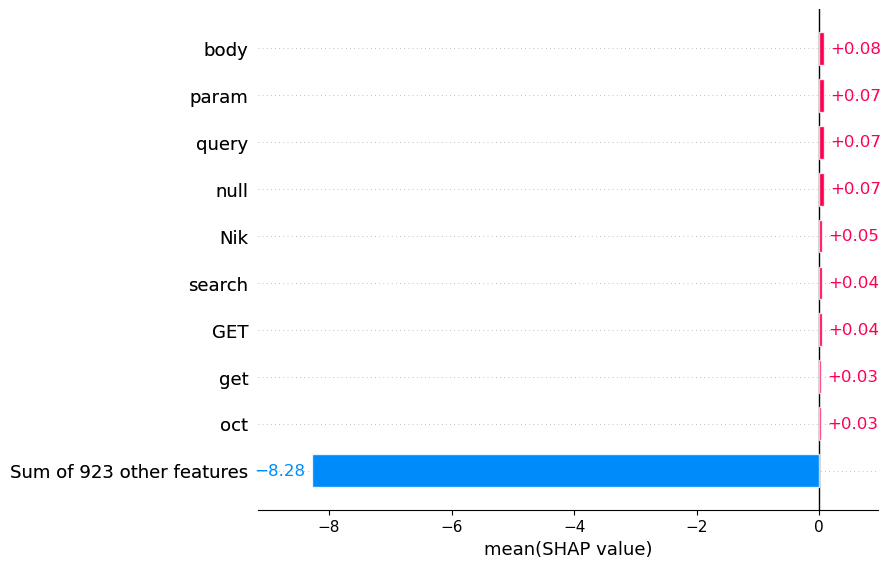

CGI feature importance


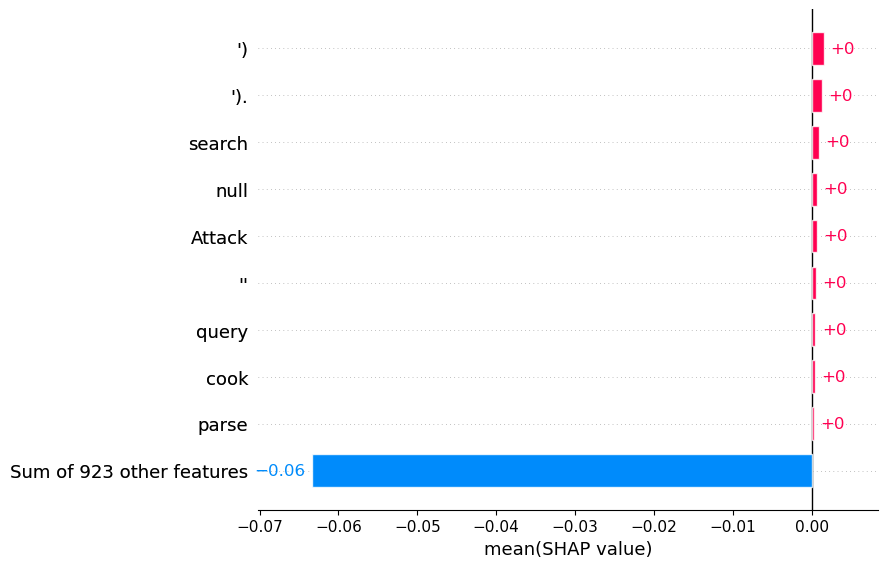

Code-execution feature importance


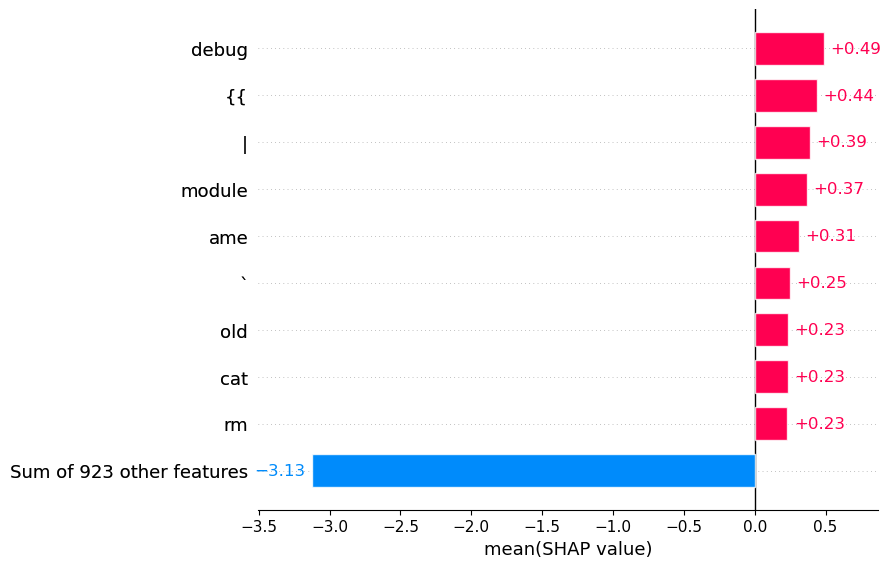

DDos feature importance


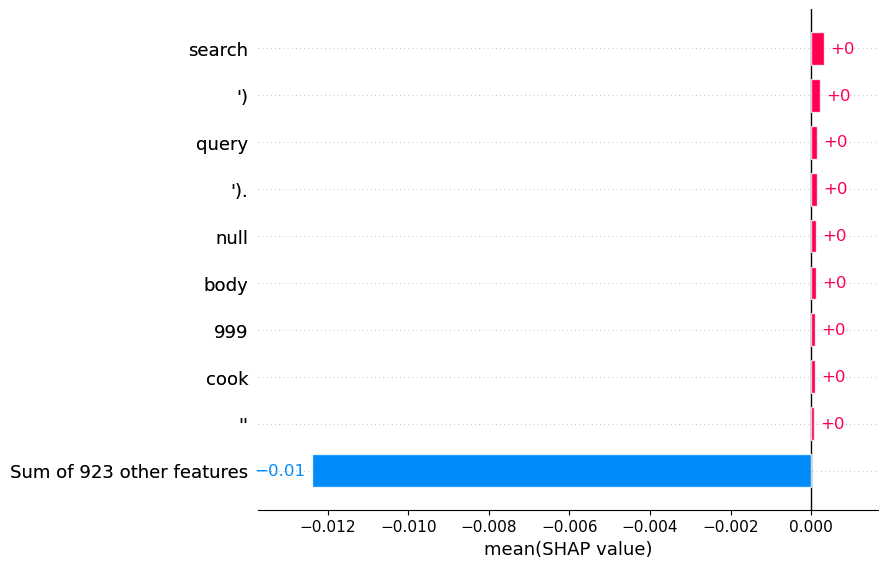

Dir-Traversal feature importance


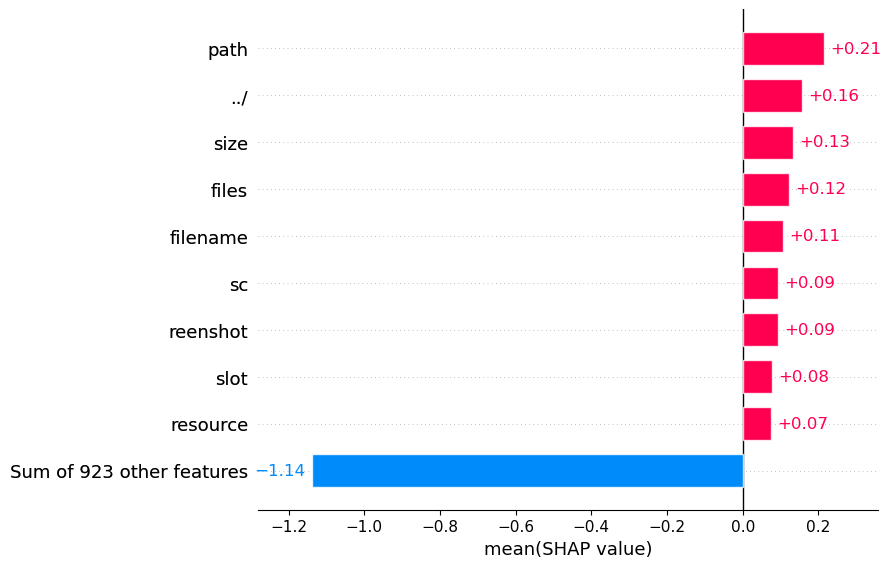

Dos feature importance


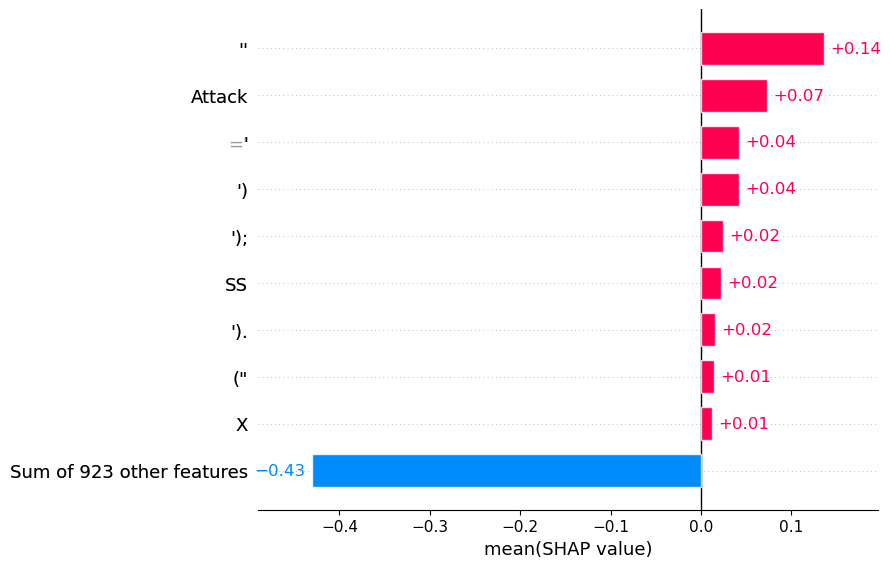

Info-Disclosure feature importance


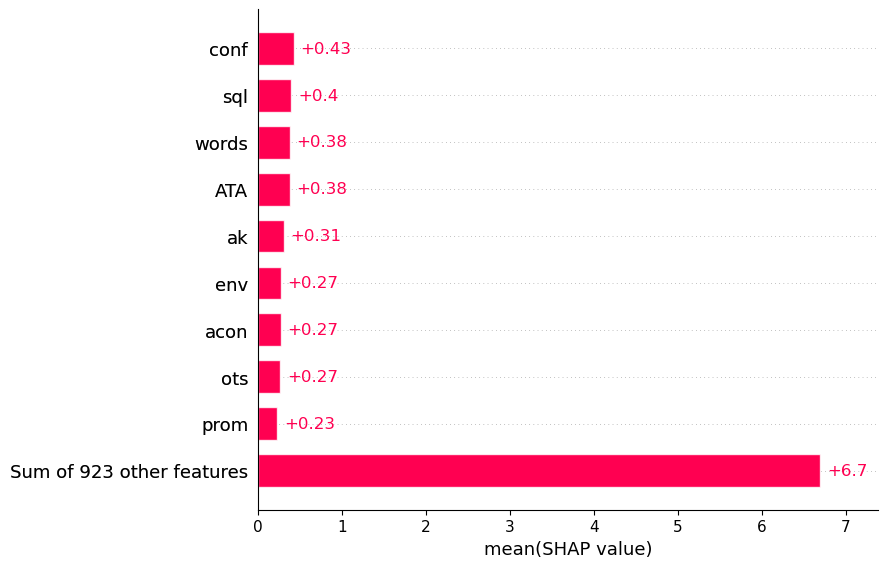

Injection feature importance


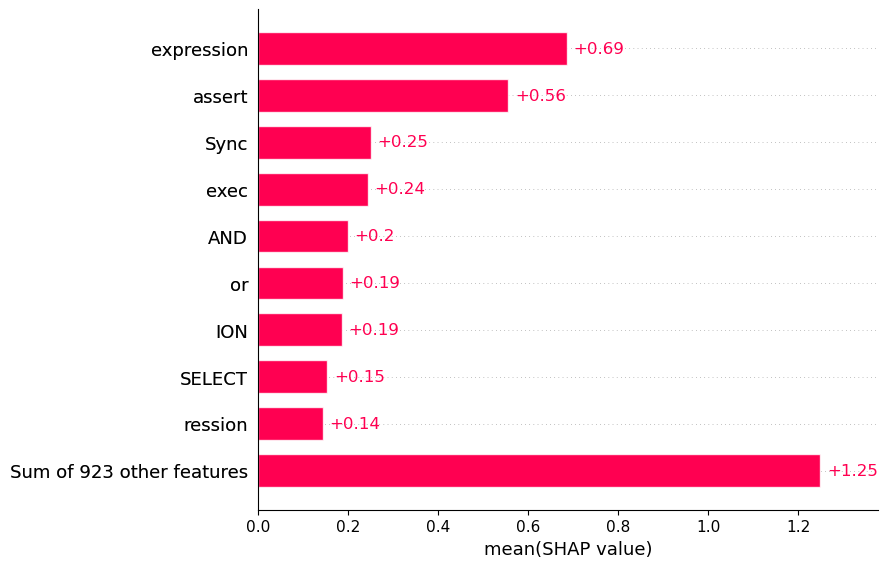

Other feature importance


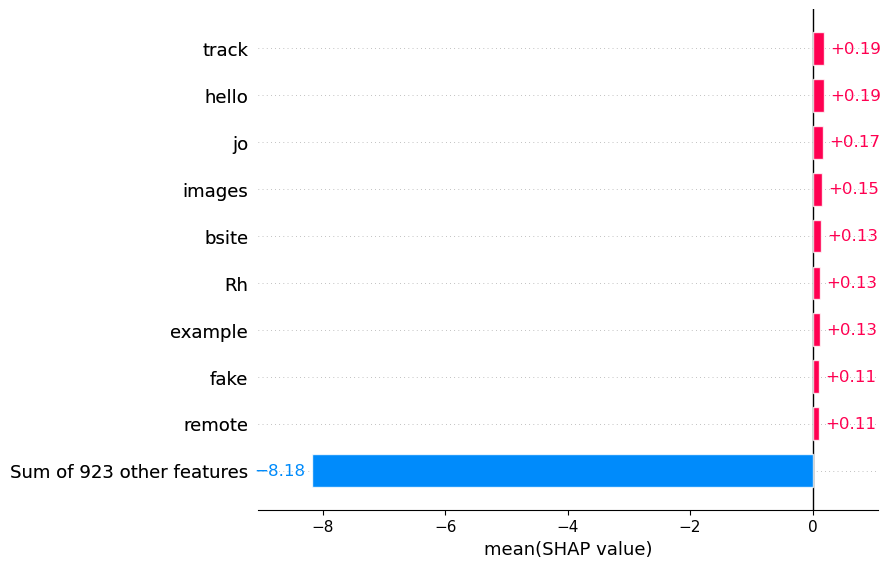

Overflow feature importance


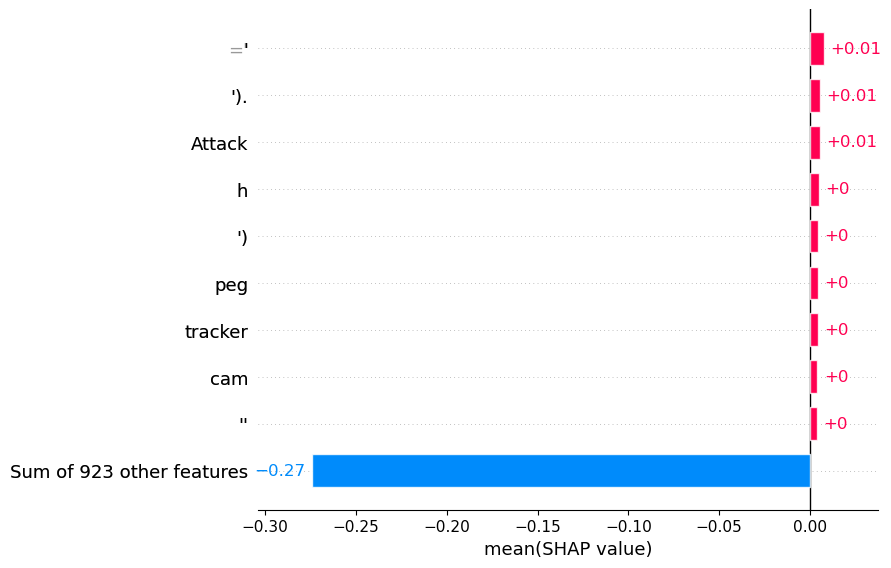

Ransonware feature importance


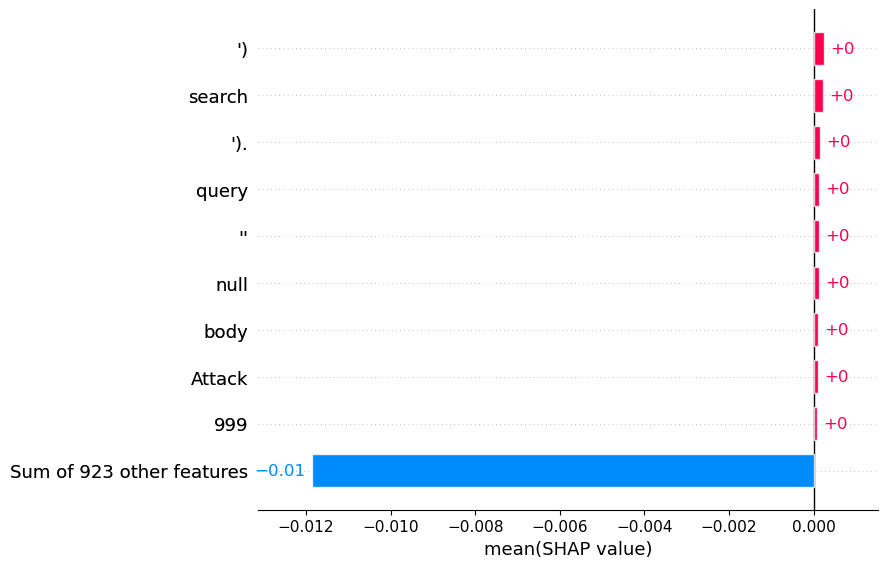

Remote-file-Inclusion feature importance


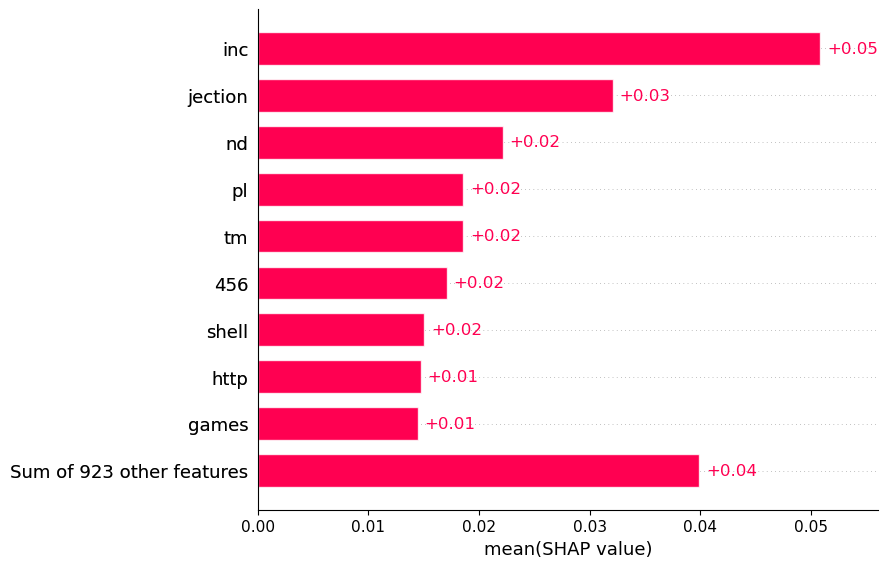

Scanner feature importance


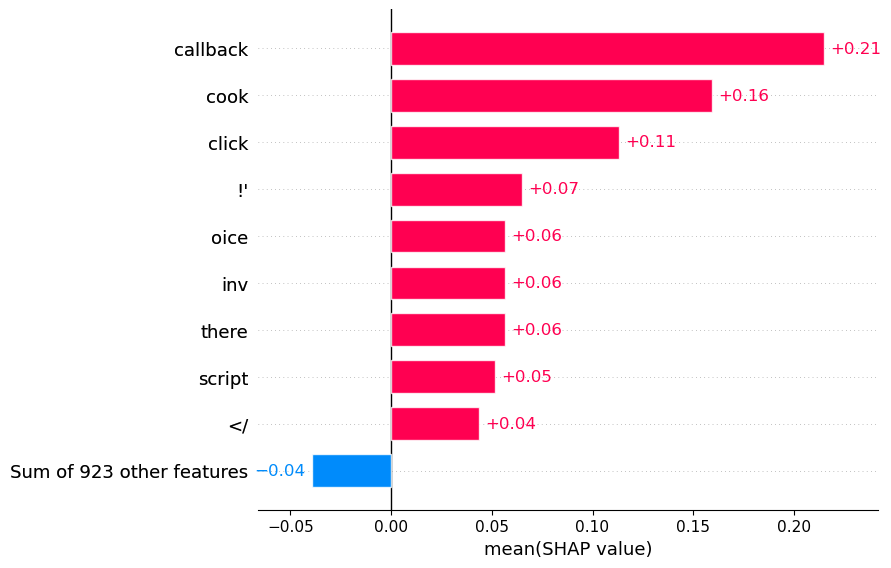

Spyware feature importance


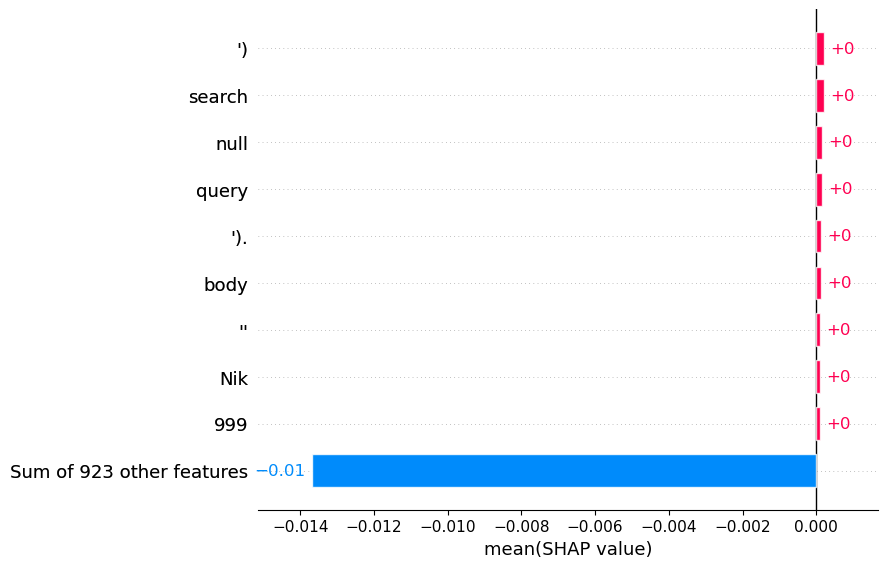

Trojan feature importance


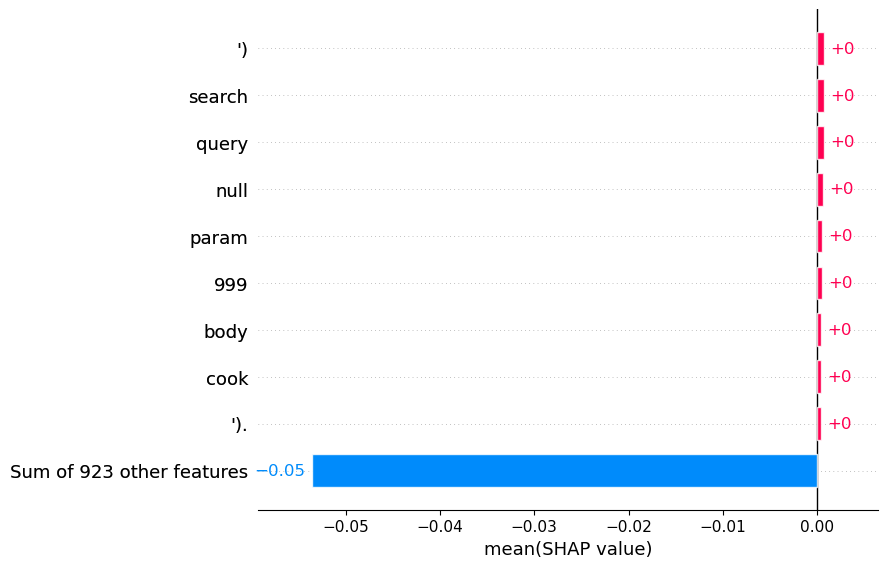

Virus feature importance


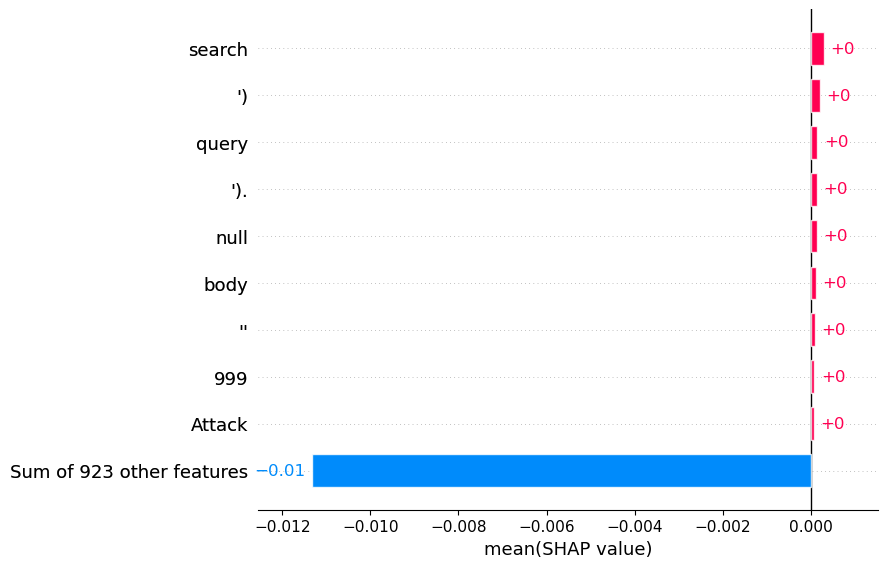

Webshell feature importance


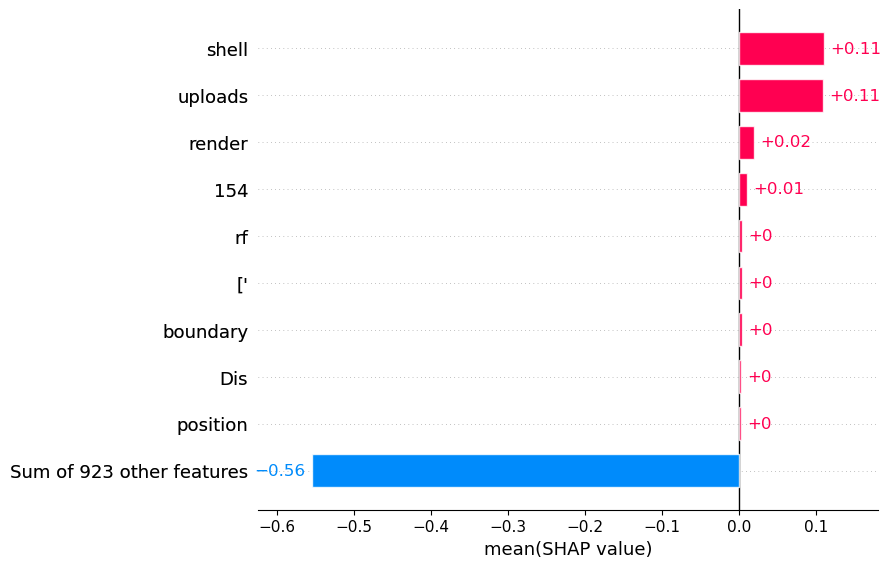

Worm feature importance


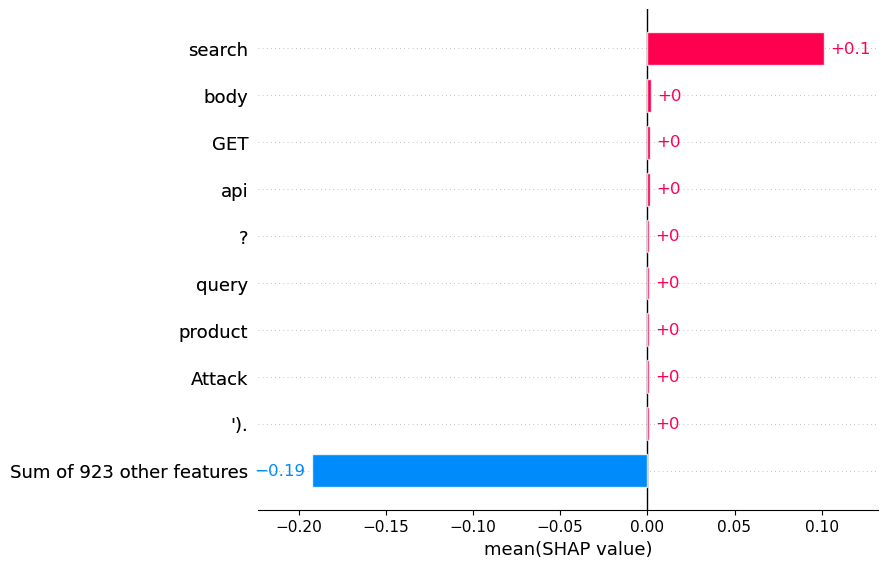

XSS feature importance


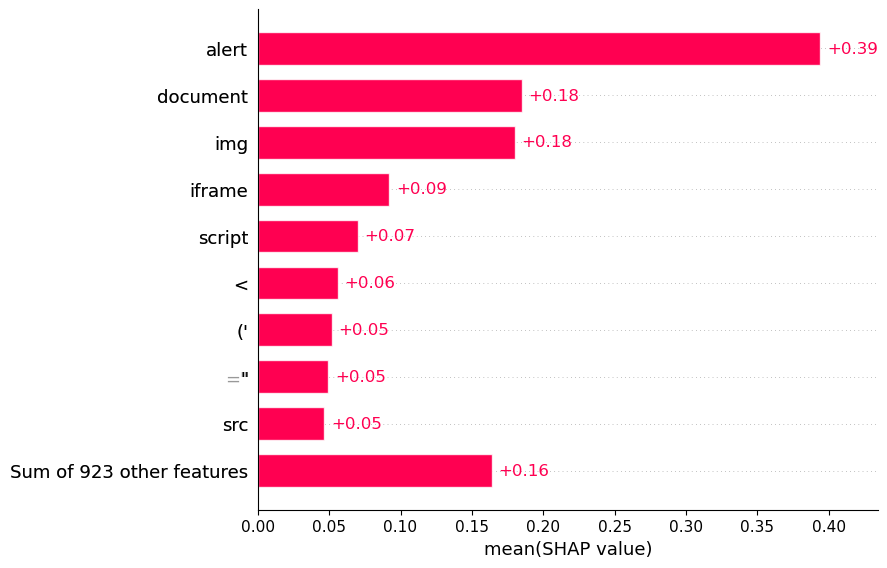

In [21]:
# SHAP
import shap

explainer = shap.Explainer(pipeline)
shap_values = explainer(inputs_to_explain)
# shap.plots.text(shap_values)
if len(shap_values)>1:
    for i,l in enumerate(class_names):
        print(f"{l} feature importance")
        shap.plots.bar(shap_values[:,:,i].mean(0), order=shap.Explanation.argsort.flip)

In [22]:
# Preprocessing shap values to represent correctly words
import numpy as np

# print(shap_values[0])
new_values = np.empty(shap_values.shape[0], dtype=object)
new_base_values = np.empty(shap_values.shape[0], dtype=object)
new_data = np.empty(shap_values.shape[0], dtype=object)
for i, x in enumerate(tqdm(inputs_to_explain)):
    tokens = tokenizer(x)
    word_ids = tokens.word_ids()
    # print(word_ids[-2])
    tmp_data = np.empty(word_ids[-2]+1, dtype=object)
    tmp_values = np.zeros((word_ids[-2]+1, len(class_names)), dtype=np.float64)
    tmp_id = 0
    string = ""
    for index, id in enumerate(word_ids):
        if id is not None:
            if id != tmp_id:
                tmp_data[tmp_id] = string
                string = ""
                tmp_id = id
            string += shap_values[i].data[index]
            tmp_values[id] = np.sum([tmp_values[id], shap_values[i].values[index]], axis=0)
    tmp_data[-1] = string
    # print(tmp_values.shape)
    new_values[i] = tmp_values
    new_base_values[i] = shap_values[i].base_values
    new_data[i] = tmp_data

new_shap_values = shap.Explanation(new_values, 
                                   base_values=new_base_values, 
                                   data=new_data, 
                                   output_names=class_names, 
                                   clustering=shap_values.clustering, 
                                   feature_names=new_data)
# print(new_shap_values.data)


100%|██████████| 258/258 [6:34:08<00:00, 91.66s/it]     


In [ ]:
def SHAP_extract_words(shap_values, num_words=5):
    important_words = {}
    important_values = {}
    if len(shap_values.data) < num_words:
        num_words = len(shap_values.data)
    sorted_indexes = np.argsort(np.abs(shap_values.values), axis=0)[-num_words:].T
    for i, l in enumerate(class_names):
        important_words[l] = []
        important_values[l] = []
        for ii in sorted_indexes[i][::-1]:
            important_words[l].append(shap_values.data[ii])
            important_values[l].append(shap_values.values[ii][i])
    average_importance = np.mean(np.abs(shap_values.values), axis=1)
    average_importance = np.argsort(average_importance)[::-1]
    important_words["avg"] = []
    important_values["avg"] = []
    for i in average_importance[:num_words]:
        important_words["avg"].append(shap_values.data[i])
        important_values["avg"].append(average_importance[i])
    return {"words": important_words, "values": important_values}
# shap.plots.text(new_shap_values)

# Saving important SHAP words (for each language and avg)) for every input tried
#     Format is dictionary with class_names as keys and a key "avg" for average between all classes
SHAP_words = []
for v in new_shap_values:
    SHAP_words.append(SHAP_extract_words(v))

# print(SHAP_words)
# print(new_shap_values)
with open("shap_results.txt", 'w') as file:
    # file.write(SHAP_words)
    for x in SHAP_words:
        for chiave, valore in x.items():
            file.write(f"{chiave}: {valore}\n")
    for v in new_shap_values:
        file.write(v)
    # file.write(new_shap_values)
# Plot of average feature importance for top 2 labels, both top 5 positive and negative
if len(shap_values)>1:
    for i,l in enumerate(class_names):
        print(f"{l} feature importance")
        shap.plots.bar(new_shap_values[:,:,i].mean(0), order=shap.Explanation.argsort.flip)


TypeError: write() argument must be str, not Explanation